In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D

# Cargar base
df = pd.read_csv("/content/Country-data (2).csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.isnull().sum()


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


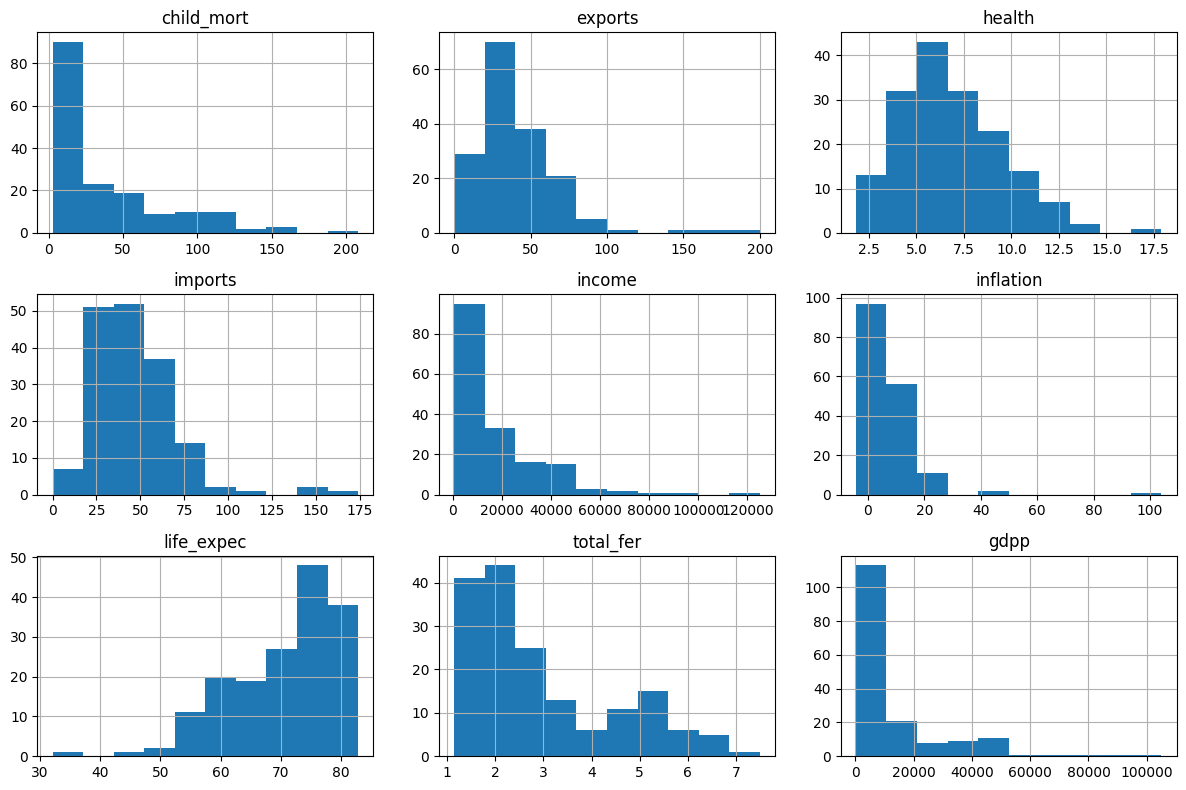

In [ ]:
# "Examinar las distribuciones de las variables numéricas"

df[["child_mort","exports","health","imports","income",
    "inflation","life_expec","total_fer","gdpp"]].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

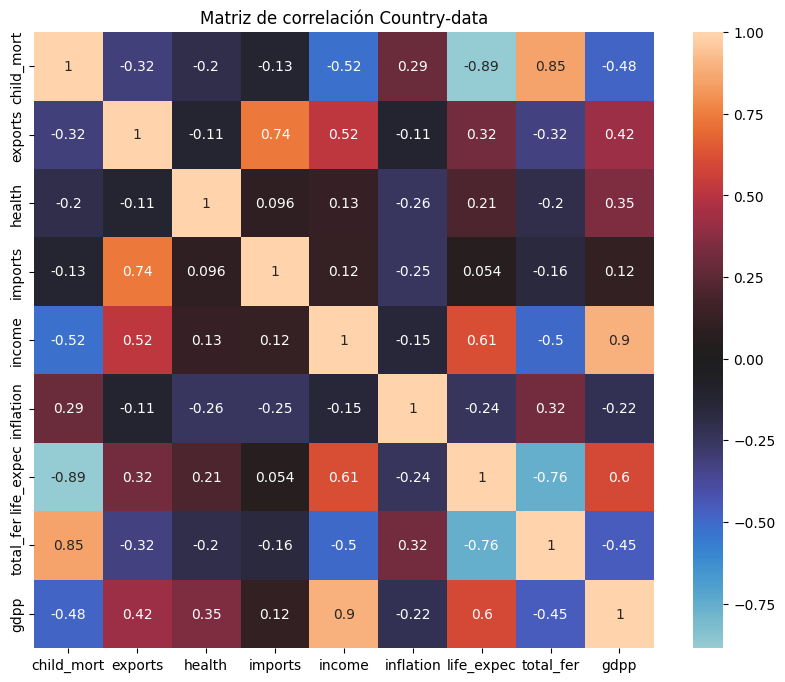

In [ ]:
# "Examinar correlaciones de las variables"

matriz_corr = df[["child_mort","exports","health","imports","income",
                  "inflation","life_expec","total_fer","gdpp"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(matriz_corr, annot=True, center=0)
plt.title("Matriz de correlación Country-data")
plt.show()

In [ ]:
# "Eliminar columnas irrelevantes o identificadores de texto."

x = df.drop(["country"], axis=1)
x

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
# "Normalizar los datos para que todas las variables contribuyan de forma equilibrada"

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
...,...,...,...,...,...,...,...,...,...
162,-0.225578,0.200917,-0.571711,0.240700,-0.738527,-0.489784,-0.852161,0.365754,-0.546913
163,-0.526514,-0.461363,-0.695862,-1.213499,-0.033542,3.616865,0.546361,-0.316678,0.029323
164,-0.372315,1.130305,0.008877,1.380030,-0.658404,0.409732,0.286958,-0.661206,-0.637754
165,0.448417,-0.406478,-0.597272,-0.517472,-0.658924,1.500916,-0.344633,1.140944,-0.637754


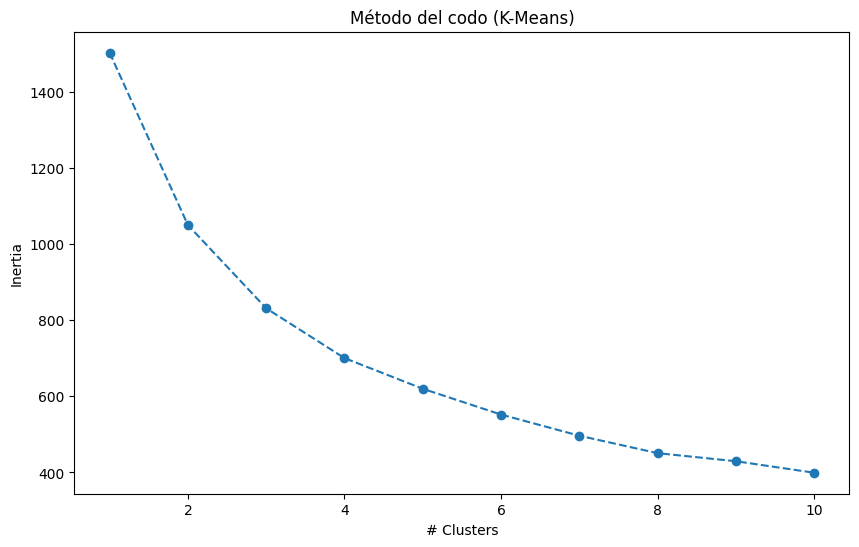

In [ ]:
# METODO DEL CODO

within = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x_scaled)
    within.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11), within, marker="o", linestyle='--')
plt.title("Método del codo (K-Means)")
plt.xlabel("# Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
# "Entrenar el algoritmo K-means con diferentes valores de k."

kmeans_3 = KMeans(n_clusters=3, init="k-means++",
                  max_iter=300, n_init=10, random_state=0)

clusters_3 = kmeans_3.fit_predict(x_scaled)

data_clusters_3 = df.copy()
data_clusters_3["CLUSTER"] = clusters_3


In [ ]:
# Analisis de Centroides
centroides = scaler.inverse_transform(kmeans_3.cluster_centers_)
data_cent = data_clusters_3.groupby('CLUSTER').mean(numeric_only=True)
data_cent['Conteo']=data_clusters_3['CLUSTER'].value_counts()
data_cent

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Conteo
CLUSTER,,,,,,,,,,
0,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,84
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,47
2,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,36


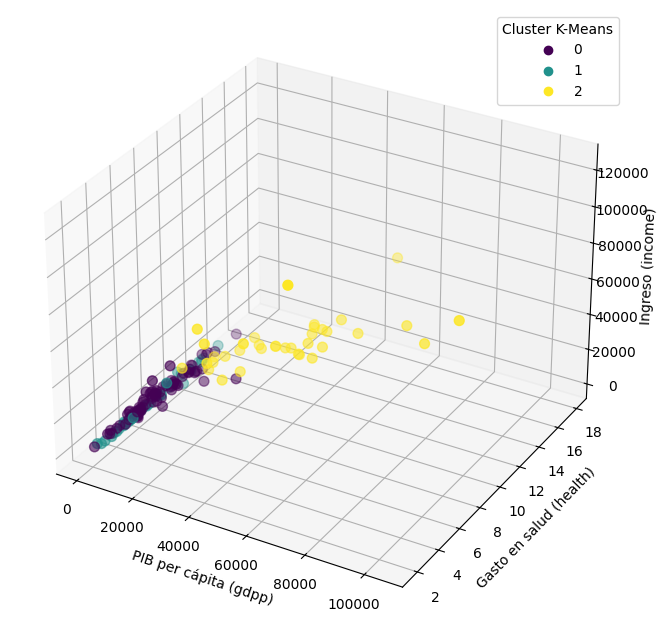

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection = '3d')
scatter = ax.scatter(data_clusters_3['gdpp'],data_clusters_3['health'],data_clusters_3['income'],
                     c = data_clusters_3['CLUSTER'], cmap='viridis', s=50)
ax.legend(*scatter.legend_elements(), title= 'Cluster K-Means')
ax.set_xlabel('PIB per cápita (gdpp)')
ax.set_ylabel('Gasto en salud (health)')
ax.set_zlabel('Ingreso (income)')
plt.show()

In [ ]:
# "Calcular el coeficiente de silueta para distintos valores de k."

for i in range(2,7):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    max_iter=300, n_init=10, random_state=0)
    etiquetas = kmeans.fit_predict(x_scaled)
    silueta = silhouette_score(x_scaled, etiquetas)
    print(f'k = {i} / Silueta: {silueta:.3f}')

k = 2 / Silueta: 0.287
k = 3 / Silueta: 0.283
k = 4 / Silueta: 0.300
k = 5 / Silueta: 0.304
k = 6 / Silueta: 0.233


In [ ]:
# "Calcular los centroides y asignar cada país a un cluster."

centroides = scaler.inverse_transform(kmeans_3.cluster_centers_)
centroides_df = pd.DataFrame(centroides, columns=x.columns)
centroides_df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444


In [ ]:
# "Calcular los centroides y asignar cada país a un cluster."


data_clusters_3[["country","CLUSTER"]]

,country,CLUSTER
0,Afghanistan,1
1,Albania,0
2,Algeria,0
3,Angola,1
4,Antigua and Barbuda,0
...,...,...
162,Vanuatu,0
163,Venezuela,0
164,Vietnam,0
165,Yemen,1


In [ ]:
# "índice de silueta, Davies-Bouldin, Calinski-Harabasz"

silueta_k = silhouette_score(x_scaled, clusters_3)
DB_k = davies_bouldin_score(x_scaled, clusters_3)
CH_k = calinski_harabasz_score(x_scaled, clusters_3)

print(f"Silueta K-Means: {silueta_k:.3f}")
print(f"Davies-Bouldin K-Means: {DB_k:.3f}")
print(f"Calinski-Harabasz K-Means: {CH_k:.3f}")

Silueta K-Means: 0.283
Davies-Bouldin K-Means: 1.277
Calinski-Harabasz K-Means: 66.235


In [ ]:
# Metodo 2: Metodos jerarquico
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

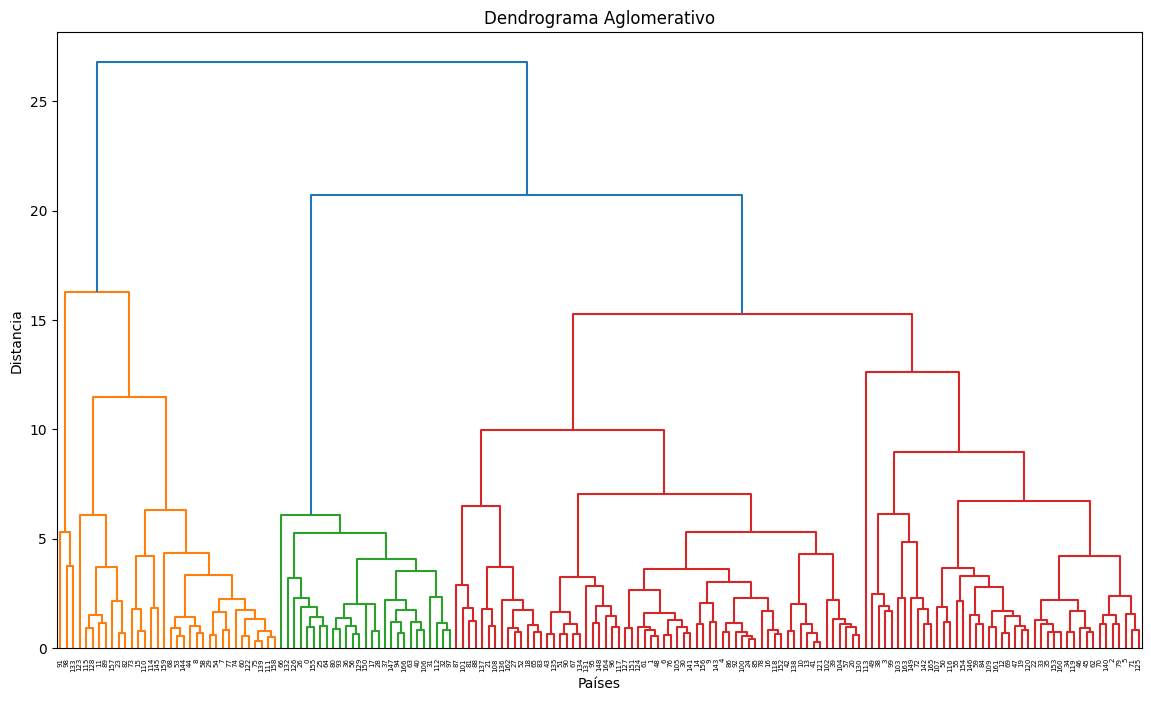

In [ ]:
# "Aplicar un modelo de clustering jerárquico como comparativo."

plt.figure(figsize=(14,8))
dendrograma = sch.dendrogram(sch.linkage(x_scaled, method='ward'))
plt.title("Dendrograma Aglomerativo")
plt.xlabel("Países")
plt.ylabel("Distancia")
plt.show()

In [ ]:
# Construyendo clusters jerárquicos
clust_aglo=AgglomerativeClustering(n_clusters=4,metric="euclidean",linkage="ward")
clust_aglo=clust_aglo.fit_predict(x_scaled)

data_cluster_aglo=df.drop(["country"],axis=1).copy()
data_cluster_aglo["CLUSTER"]=clust_aglo
data_cluster_aglo

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,CLUSTER
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


In [ ]:
# Métricas
silueta_aglo=silhouette_score(x_scaled,clust_aglo)
DB_aglo=davies_bouldin_score(x_scaled,clust_aglo)
CH_aglo=calinski_harabasz_score(x_scaled,clust_aglo)

print(f"silueta : {silueta_aglo:.2f}") # -1 a +1 mas cerca a 1 mejor (Absoluto)
print(f"davies_bouldin : {DB_aglo:.2f}") # Más cercano a 0 es mejor (relativo)
print(f"calinski_harabasz:{CH_aglo:.2f}") # Mientras mas alto es mejor (Relativo)

silueta : 0.25
davies_bouldin : 1.08
calinski_harabasz:48.26


DBSCAN

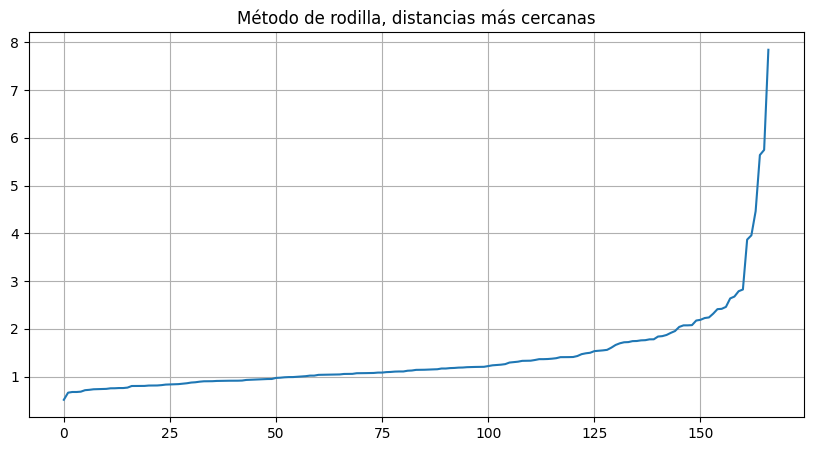

In [ ]:
# Metodología de Densidad
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
#Método de la rodilla
vecinos = NearestNeighbors(n_neighbors=4)
vecinos_fit = vecinos.fit(x_scaled)
dist , ind = vecinos_fit.kneighbors(x_scaled)
# Ordenamos distancias y gráficas
dist = np.sort(dist[:,3])
# Graficamos
plt.figure(figsize=(10,5))
plt.plot(dist)
plt.title("Método de rodilla, distancias más cercanas")
plt.grid(True)
plt.show()

In [ ]:
# Configuramos dbscan
dbscan= DBSCAN(eps=1.325,min_samples=5)
dbscan_labels=dbscan.fit_predict(x_scaled)
# Creando el dataframe
data_cluster_dbscan=df.drop(["country"],axis=1).copy()
data_cluster_dbscan["CLUSTER"]=dbscan_labels
data_cluster_dbscan

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,CLUSTER
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,-1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1
...,...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,1
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,-1
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,1
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


In [ ]:
# generar funcion de elasticidad de clusters
n_clusters_dbscan=len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)
print(f"n de clusters (sin ruido): {n_clusters_dbscan}")
print(f"Número de outliers:{list(dbscan_labels).count(-1)}")
if n_clusters_dbscan >1:
      silueta_dbscan=silhouette_score(x_scaled,dbscan_labels)
      DB_dbscan=davies_bouldin_score(x_scaled,dbscan_labels)
      CH_dbscan=calinski_harabasz_score(x_scaled,dbscan_labels)
      print(f"silueta : {silueta_dbscan:.2f}") # -1 a +1 mas cerca a 1 mejor (Absoluto)
      print(f"davies_bouldin : {DB_dbscan:.2f}") # Más cercano a 0 es mejor (relativo)
      print(f"calinski_harabasz:{CH_dbscan:.2f}") # Mientras mas alto es mejor (Relativo)
else :
  print("No se puede aplicar metricas")

n de clusters (sin ruido): 2
Número de outliers:45
silueta : 0.21
davies_bouldin : 2.64
calinski_harabasz:22.91
